# Groupe 3 — Machine Learning du trafic routier

**Sujet :** Gestion intelligente du trafic routier sur la réduction des embouteillages en temps réel.

Ce notebook utilise le fichier `dataset_trafic_ml.csv` généré par NetLogo/BehaviorSpace.

Objectif ML : prédire le **niveau de congestion 20 ticks dans le futur** (`FAIBLE`, `MOYENNE`, `FORTE`) à partir de l'état actuel du trafic.

Découpage :
- **70 %** apprentissage
- **15 %** validation
- **15 %** test

La séparation se fait par **run de simulation complet** pour éviter qu'un même run soit présent dans plusieurs ensembles.

## 1. Imports et configuration

In [18]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

try:
    from catboost import CatBoostClassifier
    CATBOOST_OK = True
except Exception as e:
    CATBOOST_OK = False
    print("CatBoost n'est pas disponible :", e)
    print("Installe-le dans une cellule avec :")
    print("%pip install catboost")

RANDOM_SEED = 42
HORIZON = 20

print("CatBoost disponible :", CATBOOST_OK)
print("Horizon de prédiction :", HORIZON, "ticks")

CatBoost disponible : True
Horizon de prédiction : 20 ticks


In [2]:
%pip install catboost

     -------------------------------------- 100.2/100.2 MB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 47.3/47.3 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 2. Localiser automatiquement le CSV BehaviorSpace

Le notebook cherche le dataset :
1. dans le même dossier que le notebook ;
2. dans le dossier parent ;
3. dans les sous-dossiers proches.

In [19]:
def trouver_dataset():
    candidats = [
        Path("dataset_trafic_ml.csv"),
        Path("../dataset_trafic_ml.csv"),
        Path("../../dataset_trafic_ml.csv"),
    ]

    for p in candidats:
        if p.exists():
            return p.resolve()

    # Recherche locale de secours
    racine = Path.cwd()
    trouves = list(racine.glob("**/dataset_trafic_ml.csv"))
    if trouves:
        return trouves[0].resolve()

    parent = racine.parent
    trouves = list(parent.glob("**/dataset_trafic_ml.csv"))
    if trouves:
        return trouves[0].resolve()

    raise FileNotFoundError(
        "dataset_trafic_ml.csv introuvable. "
        "Place le CSV dans le dossier du notebook ou dans son dossier parent."
    )

CSV_PATH = trouver_dataset()
print("Dataset trouvé :", CSV_PATH)

Dataset trouvé : C:\Master_1_projets\TP_NETLOGO_GROUPE3_FINAL_CORRIGE\dataset_trafic_ml.csv


## 3. Lire correctement le fichier BehaviorSpace

In [20]:
# BehaviorSpace peut écrire plusieurs lignes de métadonnées avant l'en-tête.
with open(CSV_PATH, "r", encoding="utf-8-sig", errors="replace") as f:
    lignes = f.readlines()

header_index = None
for i, ligne in enumerate(lignes):
    if "[run number]" in ligne and "[step]" in ligne:
        header_index = i
        break

if header_index is None:
    # Certains exports peuvent déjà commencer directement par l'en-tête
    header_index = 0

df = pd.read_csv(CSV_PATH, skiprows=header_index)

# Supprimer les colonnes entièrement vides
df = df.dropna(axis=1, how="all")

print("Dimensions brutes :", df.shape)
display(df.head())

Dimensions brutes : (168240, 34)


,[run number],control-mode,arrival-rate,ns-demand-share,initial-cars,max-cars,max-speed,fixed-green,min-green,max-green,...,average-speed-value,avg-wait-current-value,total-completed,throughput-value,congestion-index-value,congestion-level,junction-phase-code 1,junction-phase-code 2,junction-phase-code 3,junction-phase-code 4
0,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.00,0.0,0,0,0.0,FAIBLE,0,1,1,0
1,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
2,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
3,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
4,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0


## 4. Nettoyer et normaliser les noms de colonnes

In [21]:
def nettoyer_nom(col):
    col = str(col).strip()
    col = col.replace("[", "").replace("]", "")
    col = col.replace("?", "")
    col = col.replace("-", "_")
    col = col.replace(" ", "_")
    col = col.replace("/", "_")
    col = col.lower()
    col = re.sub(r"[^a-z0-9_]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

df.columns = [nettoyer_nom(c) for c in df.columns]

print("Colonnes disponibles :")
for c in df.columns:
    print(" -", c)

Colonnes disponibles :
 - run_number
 - control_mode
 - arrival_rate
 - ns_demand_share
 - initial_cars
 - max_cars
 - max_speed
 - fixed_green
 - min_green
 - max_green
 - sensor_range
 - switch_threshold
 - clearance_time
 - slow_visualization
 - visual_delay
 - csv_export
 - export_interval
 - step
 - ticks
 - count_cars
 - stopped_cars_value
 - queue_ns_value
 - queue_ew_value
 - mean_queue_value
 - average_speed_value
 - avg_wait_current_value
 - total_completed
 - throughput_value
 - congestion_index_value
 - congestion_level
 - junction_phase_code_1
 - junction_phase_code_2
 - junction_phase_code_3
 - junction_phase_code_4


## 5. Identifier automatiquement les colonnes importantes

In [22]:
def trouver_colonne_exacte_ou_partielle(possibles, contient=None):
    # exact
    for p in possibles:
        if p in df.columns:
            return p

    # partiel
    if contient:
        for c in df.columns:
            if all(mot in c for mot in contient):
                return c

    return None

run_col = trouver_colonne_exacte_ou_partielle(
    ["run_number", "run", "run_number_"],
    contient=["run"]
)

step_col = trouver_colonne_exacte_ou_partielle(
    ["step", "ticks", "tick"],
    contient=["step"]
)

congestion_col = trouver_colonne_exacte_ou_partielle(
    [
        "congestion_index_value",
        "congestion_index",
        "congestion_rate",
        "indice_congestion",
        "congestion"
    ],
    contient=["congestion", "index"]
)

niveau_col = trouver_colonne_exacte_ou_partielle(
    [
        "congestion_level_value",
        "congestion_level",
        "niveau_congestion"
    ],
    contient=["congestion", "level"]
)

mode_col = trouver_colonne_exacte_ou_partielle(
    ["control_mode", "mode_controle", "mode"],
    contient=["control", "mode"]
)

arrival_col = trouver_colonne_exacte_ou_partielle(
    ["arrival_rate", "taux_arrivee"],
    contient=["arrival", "rate"]
)

ns_share_col = trouver_colonne_exacte_ou_partielle(
    ["ns_demand_share", "part_trafic_nord_sud"],
    contient=["ns", "demand"]
)

print("run_col       =", run_col)
print("step_col      =", step_col)
print("congestion    =", congestion_col)
print("niveau        =", niveau_col)
print("mode          =", mode_col)
print("arrival_rate  =", arrival_col)
print("ns_share      =", ns_share_col)

if run_col is None or step_col is None:
    raise ValueError("Impossible d'identifier les colonnes de run et/ou de tick.")

if congestion_col is None and niveau_col is None:
    raise ValueError(
        "Impossible d'identifier une mesure de congestion. "
        "Regarde la liste des colonnes affichée plus haut."
    )

run_col       = run_number
step_col      = step
congestion    = congestion_index_value
niveau        = congestion_level
mode          = control_mode
arrival_rate  = arrival_rate
ns_share      = ns_demand_share


## 6. Nettoyage de base et création de la cible future

La cible est décalée de **20 ticks** à l'intérieur de chaque run.

In [23]:
# Convertir run et step en numérique
df[run_col] = pd.to_numeric(df[run_col], errors="coerce")
df[step_col] = pd.to_numeric(df[step_col], errors="coerce")

df = df.dropna(subset=[run_col, step_col]).copy()
df = df.sort_values([run_col, step_col]).reset_index(drop=True)

# Cible future
if niveau_col is not None:
    cible_source = (
        df[niveau_col]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace({
            "LOW": "FAIBLE",
            "MEDIUM": "MOYENNE",
            "HIGH": "FORTE",
            "MOYEN": "MOYENNE"
        })
    )
    df["_niveau_normalise"] = cible_source
    df["congestion_future"] = (
        df.groupby(run_col)["_niveau_normalise"].shift(-HORIZON)
    )
else:
    congestion_num = pd.to_numeric(df[congestion_col], errors="coerce")
    df["_congestion_num"] = congestion_num
    future_index = df.groupby(run_col)["_congestion_num"].shift(-HORIZON)

    df["congestion_future"] = pd.cut(
        future_index,
        bins=[-np.inf, 30, 60, np.inf],
        labels=["FAIBLE", "MOYENNE", "FORTE"]
    ).astype("object")

df = df.dropna(subset=["congestion_future"]).copy()
df["congestion_future"] = (
    df["congestion_future"]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Distribution de la cible future :")
print(df["congestion_future"].value_counts())

Distribution de la cible future :
FAIBLE     135489
MOYENNE     26424
FORTE        1527
Name: congestion_future, dtype: int64


## 7. Construire des variables temporelles pour améliorer la généralisation

On ajoute des tendances récentes : différence avec 5 ticks auparavant et moyenne glissante sur 5 ticks.

In [24]:
# Convertir automatiquement les colonnes numériques possibles
colonnes_interdites = {
    run_col, step_col, "congestion_future", "_niveau_normalise", "_congestion_num"
}

for c in df.columns:
    if c not in colonnes_interdites:
        # Si la grande majorité est convertible en numérique, on la garde numérique
        converted = pd.to_numeric(df[c], errors="coerce")
        if converted.notna().mean() > 0.90:
            df[c] = converted

# Colonnes candidates pour tendances
mots_tendance = [
    "queue", "file", "stopped", "arrete", "waiting", "attente",
    "speed", "vitesse", "throughput", "debit", "congestion", "count_cars",
    "nb_vehicules", "vehicles"
]

trend_cols = []
for c in df.columns:
    if c in colonnes_interdites:
        continue
    if pd.api.types.is_numeric_dtype(df[c]) and any(m in c for m in mots_tendance):
        trend_cols.append(c)

# Limiter à un nombre raisonnable
trend_cols = trend_cols[:12]

for c in trend_cols:
    df[f"{c}_delta5"] = df.groupby(run_col)[c].diff(5)
    df[f"{c}_moy5"] = (
        df.groupby(run_col)[c]
          .rolling(5, min_periods=1)
          .mean()
          .reset_index(level=0, drop=True)
    )

print("Variables de tendance ajoutées :", trend_cols)

Variables de tendance ajoutées : ['max_speed', 'count_cars', 'stopped_cars_value', 'queue_ns_value', 'queue_ew_value', 'mean_queue_value', 'average_speed_value', 'throughput_value', 'congestion_index_value']


## 8. Sélection automatique des features

On exclut les identifiants et la cible future.

In [25]:
exclure = {
    run_col,
    step_col,
    "congestion_future",
    "_niveau_normalise",
    "_congestion_num"
}

# Exclure aussi les colonnes manifestement liées à des sorties techniques BehaviorSpace
for c in df.columns:
    if c.startswith("run_number") or c.startswith("step"):
        exclure.add(c)

features = [c for c in df.columns if c not in exclure]

# Retirer colonnes constantes ou presque vides
features_valides = []
for c in features:
    serie = df[c]
    if serie.notna().sum() == 0:
        continue
    if serie.nunique(dropna=True) <= 1:
        continue
    features_valides.append(c)

features = features_valides

print("Nombre de variables retenues :", len(features))
print(features)

Nombre de variables retenues : 35
['control_mode', 'arrival_rate', 'ns_demand_share', 'ticks', 'count_cars', 'stopped_cars_value', 'queue_ns_value', 'queue_ew_value', 'mean_queue_value', 'average_speed_value', 'avg_wait_current_value', 'total_completed', 'throughput_value', 'congestion_index_value', 'congestion_level', 'junction_phase_code_1', 'junction_phase_code_2', 'junction_phase_code_3', 'junction_phase_code_4', 'count_cars_delta5', 'count_cars_moy5', 'stopped_cars_value_delta5', 'stopped_cars_value_moy5', 'queue_ns_value_delta5', 'queue_ns_value_moy5', 'queue_ew_value_delta5', 'queue_ew_value_moy5', 'mean_queue_value_delta5', 'mean_queue_value_moy5', 'average_speed_value_delta5', 'average_speed_value_moy5', 'throughput_value_delta5', 'throughput_value_moy5', 'congestion_index_value_delta5', 'congestion_index_value_moy5']


## 9. Préparer X, y et les groupes de simulation

In [26]:
X = df[features].copy()
y = df["congestion_future"].copy()
groups = df[run_col].astype(int).copy()

categorical_features = []

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna("INCONNU").astype(str)
        categorical_features.append(col)
    else:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        mediane = X[col].median()
        if pd.isna(mediane):
            mediane = 0
        X[col] = X[col].fillna(mediane)

print("X :", X.shape)
print("Classes :", sorted(y.unique()))
print("Variables catégorielles :", categorical_features)

X : (163440, 35)
Classes : ['FAIBLE', 'FORTE', 'MOYENNE']
Variables catégorielles : ['control_mode', 'congestion_level']


## 10. Découpage 70 % / 15 % / 15 % par run

Aucune ligne d'un même run ne peut se retrouver dans plusieurs ensembles.

In [27]:
split1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(split1.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
g_train = groups.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()
g_temp = groups.iloc[temp_idx].copy()

split2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_SEED
)

val_rel_idx, test_rel_idx = next(
    split2.split(X_temp, y_temp, groups=g_temp)
)

X_val = X_temp.iloc[val_rel_idx].copy()
y_val = y_temp.iloc[val_rel_idx].copy()
g_val = g_temp.iloc[val_rel_idx].copy()

X_test = X_temp.iloc[test_rel_idx].copy()
y_test = y_temp.iloc[test_rel_idx].copy()
g_test = g_temp.iloc[test_rel_idx].copy()

print("TRAIN :", X_train.shape, "| runs :", g_train.nunique())
print("VALID :", X_val.shape,   "| runs :", g_val.nunique())
print("TEST  :", X_test.shape,  "| runs :", g_test.nunique())

runs_train = set(g_train.unique())
runs_val = set(g_val.unique())
runs_test = set(g_test.unique())

print("Train ∩ Validation :", len(runs_train & runs_val))
print("Train ∩ Test       :", len(runs_train & runs_test))
print("Validation ∩ Test  :", len(runs_val & runs_test))

TRAIN : (114408, 35) | runs : 168
VALID : (24516, 35) | runs : 36
TEST  : (24516, 35) | runs : 36
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


## 11. Vérifier la distribution des classes

In [28]:
def distrib(nom, serie):
    print(f"\n{nom}")
    print(serie.value_counts())
    print((serie.value_counts(normalize=True) * 100).round(2).astype(str) + " %")

distrib("TRAIN", y_train)
distrib("VALIDATION", y_val)
distrib("TEST", y_test)


TRAIN
FAIBLE     95160
MOYENNE    18214
FORTE       1034
Name: congestion_future, dtype: int64
FAIBLE     83.18 %
MOYENNE    15.92 %
FORTE        0.9 %
Name: congestion_future, dtype: object

VALIDATION
FAIBLE     19997
MOYENNE     4291
FORTE        228
Name: congestion_future, dtype: int64
FAIBLE     81.57 %
MOYENNE     17.5 %
FORTE       0.93 %
Name: congestion_future, dtype: object

TEST
FAIBLE     20332
MOYENNE     3919
FORTE        265
Name: congestion_future, dtype: int64
FAIBLE     82.93 %
MOYENNE    15.99 %
FORTE       1.08 %
Name: congestion_future, dtype: object


## 12. Entraîner CatBoost

Réglages choisis pour limiter le surapprentissage :
- profondeur modérée ;
- learning rate faible ;
- régularisation L2 ;
- pondération automatique des classes ;
- early stopping sur la validation.

In [31]:
if not CATBOOST_OK:
    raise ImportError(
        "CatBoost n'est pas installé dans ce noyau Jupyter. "
        "Exécute une cellule avec `%pip install catboost`, puis redémarre le kernel."
    )

cat_indices = [X_train.columns.get_loc(c) for c in categorical_features]

model = CatBoostClassifier(
    iterations=1800,
    depth=8,
    learning_rate=0.035,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="SqrtBalanced",
    l2_leaf_reg=8,
    random_strength=1.0,
    bagging_temperature=1.0,
    random_seed=RANDOM_SEED,
    verbose=100,
    allow_writing_files=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_indices,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=150
)

print("Meilleure itération :", model.get_best_iteration())

0:	learn: 0.7484947	test: 0.7545507	best: 0.7545507 (0)	total: 396ms	remaining: 11m 52s
100:	learn: 0.8247973	test: 0.8247930	best: 0.8247930 (100)	total: 40.6s	remaining: 11m 22s
200:	learn: 0.8649079	test: 0.8571091	best: 0.8572718 (197)	total: 1m 20s	remaining: 10m 38s
300:	learn: 0.8856152	test: 0.8688865	best: 0.8694736 (298)	total: 1m 58s	remaining: 9m 51s
400:	learn: 0.8998841	test: 0.8744226	best: 0.8744226 (400)	total: 2m 38s	remaining: 9m 13s
500:	learn: 0.9097114	test: 0.8786804	best: 0.8787139 (497)	total: 3m 17s	remaining: 8m 33s
600:	learn: 0.9173106	test: 0.8803774	best: 0.8803897 (595)	total: 3m 57s	remaining: 7m 54s
700:	learn: 0.9232883	test: 0.8808781	best: 0.8811784 (694)	total: 4m 41s	remaining: 7m 21s
800:	learn: 0.9287951	test: 0.8824075	best: 0.8827690 (784)	total: 5m 23s	remaining: 6m 43s
900:	learn: 0.9332231	test: 0.8824277	best: 0.8831128 (857)	total: 6m 3s	remaining: 6m 2s
1000:	learn: 0.9367991	test: 0.8823972	best: 0.8831128 (857)	total: 6m 44s	remaining:

## 13. Évaluation sur validation

In [32]:
pred_val = model.predict(X_val).ravel()

val_metrics = {
    "accuracy": accuracy_score(y_val, pred_val),
    "balanced_accuracy": balanced_accuracy_score(y_val, pred_val),
    "f1_macro": f1_score(y_val, pred_val, average="macro")
}

for k, v in val_metrics.items():
    print(f"{k:20s}: {v:.4f}")

accuracy            : 0.9169
balanced_accuracy   : 0.8293
f1_macro            : 0.7882


## 14. Évaluation finale sur le jeu TEST

Le test n'a pas été utilisé pour choisir les hyperparamètres ni pour l'early stopping.

In [33]:
pred_test = model.predict(X_test).ravel()

test_metrics = {
    "accuracy": accuracy_score(y_test, pred_test),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_test),
    "f1_macro": f1_score(y_test, pred_test, average="macro")
}

print("=== RESULTATS TEST ===")
for k, v in test_metrics.items():
    print(f"{k:20s}: {v:.4f}")

rapport = classification_report(y_test, pred_test, digits=4)
print("\nRapport de classification :\n")
print(rapport)

=== RESULTATS TEST ===
accuracy            : 0.9250
balanced_accuracy   : 0.8260
f1_macro            : 0.8047

Rapport de classification :

              precision    recall  f1-score   support

      FAIBLE     0.9572    0.9614    0.9593     20332
       FORTE     0.6316    0.7698    0.6939       265
     MOYENNE     0.7758    0.7469    0.7611      3919

    accuracy                         0.9250     24516
   macro avg     0.7882    0.8260    0.8047     24516
weighted avg     0.9247    0.9250    0.9248     24516



## 15. Matrice de confusion

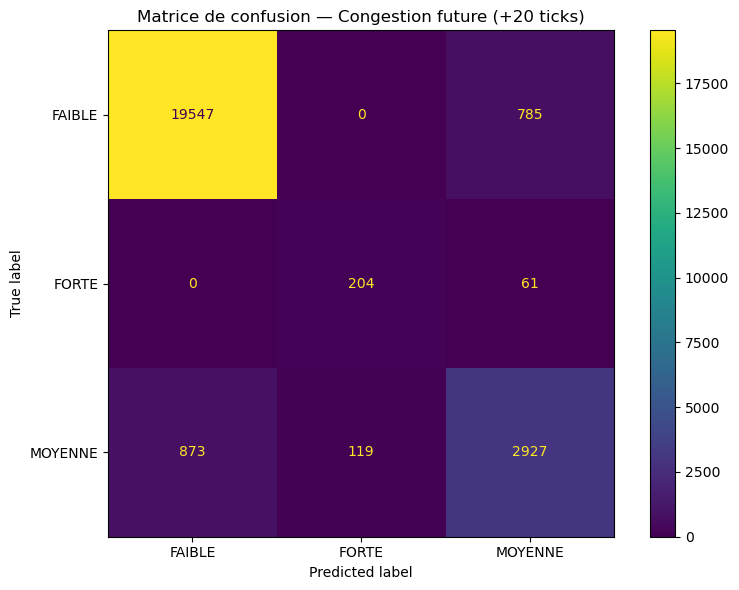

In [34]:
classes = sorted(y.unique())

cm = confusion_matrix(y_test, pred_test, labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion — Congestion future (+20 ticks)")
plt.tight_layout()
plt.show()

## 16. Importance des variables

,Variable,Importance
0,control_mode,15.450132
3,ticks,15.209901
10,avg_wait_current_value,4.592776
15,junction_phase_code_1,3.908736
16,junction_phase_code_2,3.874863
17,junction_phase_code_3,3.825099
18,junction_phase_code_4,3.825050
31,throughput_value_delta5,3.609732
9,average_speed_value,3.055170
13,congestion_index_value,3.050523


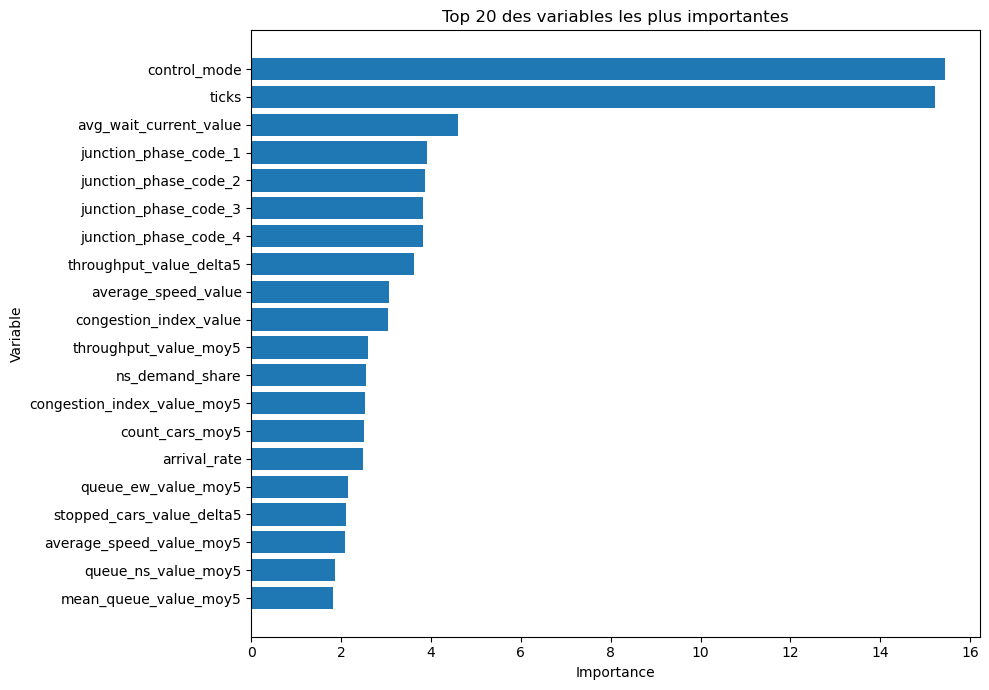

In [35]:
importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": model.get_feature_importance()
}).sort_values("Importance", ascending=False)

display(importance.head(25))

top = importance.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top["Variable"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 20 des variables les plus importantes")
plt.tight_layout()
plt.show()

## 17. Sauvegarder tous les résultats

In [36]:
RESULTATS = Path("resultats_ml")
RESULTATS.mkdir(exist_ok=True)

# Modèle
model.save_model(str(RESULTATS / "modele_catboost_trafic.cbm"))

# Prédictions
pred_df = X_test.copy()
pred_df["run"] = g_test.values
pred_df["reel"] = y_test.values
pred_df["prediction"] = pred_test
pred_df.to_csv(RESULTATS / "predictions_test.csv", index=False)

# Importance
importance.to_csv(RESULTATS / "importance_variables.csv", index=False)

# Rapport texte
with open(RESULTATS / "rapport_classification.txt", "w", encoding="utf-8") as f:
    f.write(rapport)

# Métriques
metriques = {
    "horizon_ticks": HORIZON,
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "train_runs": int(g_train.nunique()),
    "validation_runs": int(g_val.nunique()),
    "test_runs": int(g_test.nunique()),
    "validation": {k: float(v) for k, v in val_metrics.items()},
    "test": {k: float(v) for k, v in test_metrics.items()},
    "best_iteration": int(model.get_best_iteration())
}

with open(RESULTATS / "metriques.json", "w", encoding="utf-8") as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)

# Images
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d")
plt.title("Matrice de confusion — Congestion future (+20 ticks)")
plt.tight_layout()
plt.savefig(RESULTATS / "matrice_confusion.png", dpi=200, bbox_inches="tight")
plt.close()

top = importance.head(20).sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(top["Variable"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 20 des variables les plus importantes")
plt.tight_layout()
plt.savefig(RESULTATS / "importance_variables.png", dpi=200, bbox_inches="tight")
plt.close()

print("Résultats enregistrés dans :", RESULTATS.resolve())

Résultats enregistrés dans : C:\Master_1_projets\TP_NETLOGO_GROUPE3_FINAL_CORRIGE\ML_JUPYTER_GROUPE3\resultats_ml


## 18. Résumé final

À la fin de l'exécution, utilise principalement :
- `resultats_ml/metriques.json`
- `resultats_ml/rapport_classification.txt`
- `resultats_ml/matrice_confusion.png`
- `resultats_ml/importance_variables.png`
- `resultats_ml/predictions_test.csv`
- `resultats_ml/modele_catboost_trafic.cbm`

Ces fichiers servent pour le rapport et la présentation du TP.